In [63]:
# Setup for Kaggle or Google Colab environments
# Run this cell to install any missing dependencies!
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn mplsoccer tqdm

# Player Style Clustering — Preprocessing & K-Means

**Input:** `player_style_features_pl_laliga_seriea_1516.csv` (1016 players, 29 numeric features) and the EDA findings from `01_data_and_eda.ipynb`.

**Part A** builds three parallel feature matrices (unscaled, `StandardScaler`, `RobustScaler`) after handling structural missing values. **Part B** runs K-Means across all three, selects `k` via Elbow/Silhouette/Gap Statistic, cross-checks cluster agreement between scalings with the Adjusted Rand Index, and fits the final model.

## Setup

In [64]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# Read from the local repo's data/ if present; otherwise (e.g. a bare Kaggle/Colab notebook)
# fall back to a writable working directory - /kaggle/input/... is read-only, so outputs
# can never be written there.
_LOCAL_DATA_DIR = next((p for p in [Path("../data"), Path("data"), Path("../../data")] if p.exists()), None)
if _LOCAL_DATA_DIR is not None:
    DATA_DIR = _LOCAL_DATA_DIR.resolve()
else:
    DATA_DIR = Path("/kaggle/working/data")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Using data directory:", DATA_DIR)

Using data directory: /kaggle/working/data


## Part A — Preprocessing

No feature needs to be dropped for redundancy (EDA found no pair correlated above 0.9), and every feature is already numeric (no categorical encoding needed) — the only preprocessing steps are imputing the structurally-missing success-rate columns and comparing scaling strategies.

In [65]:
df = pd.read_csv(DATA_DIR / "extract-feature" / "player_style_features_pl_laliga_seriea_1516.csv", encoding="utf-8-sig")

id_cols = ["player_id", "player_name", "primary_team", "competitions_played",
           "n_matches_played", "total_minutes_played"]

feature_cols = [
    "shots_p90", "np_goals_p90", "avg_shot_distance", "dribbles_p90", "dribble_success_rate",
    "touches_p90", "touches_in_box_p90", "passes_p90", "pass_completion_pct", "key_passes_p90",
    "assists_p90", "crosses_p90", "through_balls_p90", "long_balls_p90", "avg_pass_length",
    "pressures_p90", "tackles_p90", "tackle_success_rate", "interceptions_p90",
    "interception_success_rate", "ball_recoveries_p90", "clearances_p90", "aerial_won_p90",
    "fouls_committed_p90", "fouls_won_p90", "avg_location_x", "avg_location_y",
    "std_location_x", "std_location_y",
]

hidden_cols = ["primary_position"]

missing_in_df = [c for c in id_cols + feature_cols + hidden_cols if c not in df.columns]
assert not missing_in_df, f"Missing expected columns: {missing_in_df}"
print(f"Shape: {df.shape} | feature columns: {len(feature_cols)}")

Shape: (1016, 36) | feature columns: 29


### Handling missing values

The 4 columns with missing values are conditional success rates or a conditional average — `NaN` when a player never attempted the underlying action (their corresponding `..._p90` rate is already near 0, naturally reflecting "not this player's game"). Imputing the **column median** is a neutral choice — it doesn't push these players toward an artificially high or low success signal in either direction, unlike filling with 0 (which would falsely mean "always failed").

In [66]:
missing_before = df[feature_cols].isna().sum()
print("Missing before imputation:")
print(missing_before[missing_before > 0])

X_raw = df[feature_cols].copy()
impute_values = {}
for col in feature_cols:
    if X_raw[col].isna().any():
        median_val = X_raw[col].median()
        impute_values[col] = median_val
        X_raw[col] = X_raw[col].fillna(median_val)

print("\nMedian values used for imputation:")
for col, val in impute_values.items():
    print(f"  {col}: {val:.4f}")

print("\nMissing after imputation:", X_raw.isna().sum().sum())

Missing before imputation:
avg_shot_distance            75
dribble_success_rate         42
tackle_success_rate          70
interception_success_rate    72
dtype: int64

Median values used for imputation:
  avg_shot_distance: 19.7162
  dribble_success_rate: 0.5833
  tackle_success_rate: 0.6087
  interception_success_rate: 0.6187

Missing after imputation: 0


### Three scaling variants: unscaled / StandardScaler / RobustScaler

In [67]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_unscaled = X_raw.copy()
X_standard = pd.DataFrame(standard_scaler.fit_transform(X_raw), columns=feature_cols, index=X_raw.index)
X_robust = pd.DataFrame(robust_scaler.fit_transform(X_raw), columns=feature_cols, index=X_raw.index)

print("X_unscaled:", X_unscaled.shape)
print("X_standard:", X_standard.shape)
print("X_robust  :", X_robust.shape)

X_unscaled: (1016, 29)
X_standard: (1016, 29)
X_robust  : (1016, 29)


### Quantitative comparison

In [68]:
def summarize(X, label):
    s = X.describe().T[["mean", "std", "min", "max"]]
    s.columns = pd.MultiIndex.from_product([[label], s.columns])
    return s

comparison = pd.concat(
    [summarize(X_unscaled, "Unscaled"), summarize(X_standard, "StandardScaler"), summarize(X_robust, "RobustScaler")],
    axis=1,
)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
comparison

Unscaled                       StandardScaler        \
                              mean    std    min     max           mean   std   
shots_p90                    1.162  1.015  0.000   6.268         -0.000 1.000   
np_goals_p90                 0.108  0.147  0.000   1.076         -0.000 1.000   
avg_shot_distance           19.453  5.219  5.431  35.496         -0.000 1.000   
dribbles_p90                 1.608  1.416  0.000   7.852         -0.000 1.000   
dribble_success_rate         0.610  0.174  0.000   1.000          0.000 1.000   
touches_p90                127.726 35.303 49.315 305.988          0.000 1.000   
touches_in_box_p90           5.075  5.248  0.000  30.176         -0.000 1.000   
passes_p90                  42.383 13.541 14.100 113.332         -0.000 1.000   
pass_completion_pct          0.750  0.085  0.391   0.917         -0.000 1.000   
key_passes_p90               0.746  0.604  0.000   3.542         -0.000 1.000   
assists_p90                  0.078  0.093  0.000   0.561          0.000 1.000   
crosses_p90                  1.163  1.180  0.000   6.422          0.000 1.000   
through_balls_p90            0.189  0.233  0.000   3.438          0.000 1.000   
long_balls_p90               8.699  5.200  0.684  29.795         -0.000 1.000   
avg_pass_length             21.673  8.264 11.668  63.403          0.000 1.000   
pressures_p90               14.235  6.539  0.000  40.177          0.000 1.000   
tackles_p90                  1.739  0.962  0.000   4.658          0.000 1.000   
tackle_success_rate          0.608  0.105  0.111   1.000          0.000 1.000   
interceptions_p90            1.136  0.734  0.000   3.539         -0.000 1.000   
interception_success_rate    0.619  0.135  0.000   1.000          0.000 1.000   
ball_recoveries_p90          4.628  1.391  1.315   9.624          0.000 1.000   
clearances_p90               2.134  2.011  0.000  10.265          0.000 1.000   
aerial_won_p90               1.899  1.490  0.000  12.707          0.000 1.000   
fouls_committed_p90          1.366  0.722  0.000   4.333         -0.000 1.000   
fouls_won_p90                1.296  0.861  0.000   5.872         -0.000 1.000   
avg_location_x              59.230 18.870  7.195  87.325          0.000 1.000   
avg_location_y              39.937 14.048  8.969  72.000         -0.000 1.000   
std_location_x              21.865  5.051  5.111  31.967         -0.000 1.000   
std_location_y              17.663  5.331  6.444  31.963          0.000 1.000   

                                        RobustScaler                      
                             min    max         mean   std    min    max  
shots_p90                 -1.145  5.033        0.239 0.704 -0.566  3.779  
np_goals_p90              -0.734  6.568        0.327 0.988 -0.397  6.810  
avg_shot_distance         -2.688  3.076       -0.037 0.741 -2.028  2.240  
dribbles_p90              -1.136  4.411        0.195 0.781 -0.691  3.637  
dribble_success_rate      -3.510  2.242        0.139 0.903 -3.028  2.163  
touches_p90               -2.222  5.052        0.040 0.777 -1.685  3.962  
touches_in_box_p90        -0.967  4.785        0.371 0.880 -0.480  4.579  
passes_p90                -2.090  5.242        0.015 0.719 -1.487  3.782  
pass_completion_pct       -4.214  1.958       -0.088 0.790 -3.416  1.458  
key_passes_p90            -1.237  4.635        0.095 0.707 -0.779  3.370  
assists_p90               -0.841  5.202        0.213 0.766 -0.432  4.197  
crosses_p90               -0.986  4.460        0.211 0.686 -0.466  3.269  
through_balls_p90         -0.813 13.941        0.291 1.025 -0.542 14.566  
long_balls_p90            -1.542  4.059        0.105 0.937 -1.339  3.907  
avg_pass_length           -1.211  5.052        0.366 1.643 -1.623  8.662  
pressures_p90             -2.178  3.969       -0.024 0.785 -1.732  3.089  
tackles_p90               -1.808  3.035        0.051 0.739 -1.283  2.292  
tackle_success_rate       -4.740  3.732       -0.002 0.866 -4.105  3.228  
interceptions_

### RobustScaler is not always gentler on outliers

Checking two heavily right-skewed features (`np_goals_p90`, `through_balls_p90`) against the intuition that RobustScaler always dampens extreme values more than StandardScaler.

In [69]:
check_cols = ["np_goals_p90", "through_balls_p90"]

for col in check_cols:
    print(f"{col}:")
    print(f"  Unscaled       max = {X_unscaled[col].max():.3f}")
    print(f"  StandardScaler max = {X_standard[col].max():.3f}")
    print(f"  RobustScaler   max = {X_robust[col].max():.3f}")
    print()

np_goals_p90:
  Unscaled       max = 1.076
  StandardScaler max = 6.568
  RobustScaler   max = 6.810

through_balls_p90:
  Unscaled       max = 3.438
  StandardScaler max = 13.941
  RobustScaler   max = 14.566



For these two features, **RobustScaler's max value is actually higher than StandardScaler's** (e.g. `np_goals_p90` reaches ≈6.6 under StandardScaler but ≈6.8 under RobustScaler). Since neither scaler is uniformly "safer," both are carried forward into the K-Means comparison in Part B rather than picking one on theoretical grounds alone.

### Visual comparison: box plots

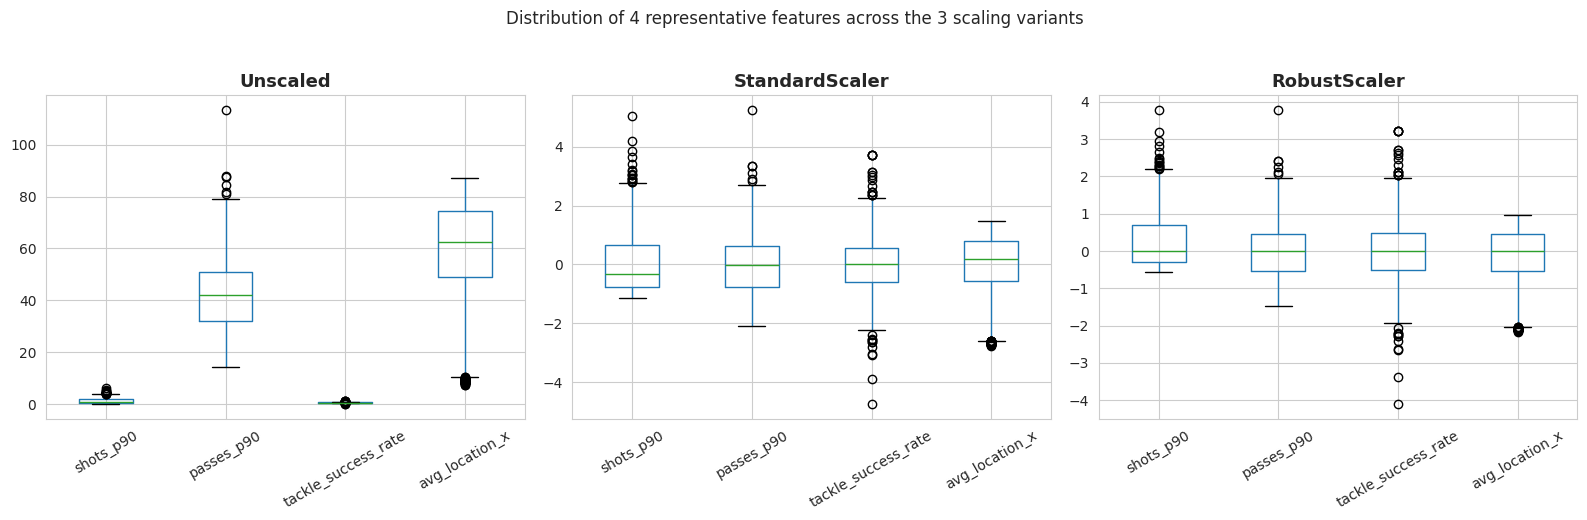

In [70]:
sample_cols = ["shots_p90", "passes_p90", "tackle_success_rate", "avg_location_x"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (X, label) in zip(
    axes, [(X_unscaled, "Unscaled"), (X_standard, "StandardScaler"), (X_robust, "RobustScaler")]
):
    X[sample_cols].boxplot(ax=ax, rot=30)
    ax.set_title(label)

plt.suptitle("Distribution of 4 representative features across the 3 scaling variants", y=1.03)
plt.tight_layout()
plt.show()

### Save the three X versions + held-out y

In [71]:
def build_output(X, id_df):
    return pd.concat([id_df.reset_index(drop=True), X.reset_index(drop=True)], axis=1)


PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

id_df = df[id_cols].copy()
hidden_df = pd.concat([id_df.reset_index(drop=True), df[hidden_cols].reset_index(drop=True)], axis=1)

build_output(X_unscaled, id_df).to_csv(PROCESSED_DIR / "player_X_unscaled.csv", index=False, encoding="utf-8-sig")
build_output(X_standard, id_df).to_csv(PROCESSED_DIR / "player_X_standard_scaled.csv", index=False, encoding="utf-8-sig")
build_output(X_robust, id_df).to_csv(PROCESSED_DIR / "player_X_robust_scaled.csv", index=False, encoding="utf-8-sig")
hidden_df.to_csv(PROCESSED_DIR / "player_y_hidden.csv", index=False, encoding="utf-8-sig")

print("Saved:")
for fname in ["player_X_unscaled.csv", "player_X_standard_scaled.csv", "player_X_robust_scaled.csv", "player_y_hidden.csv"]:
    print(" -", PROCESSED_DIR / fname)

Saved:
 - /kaggle/working/data/processed/player_X_unscaled.csv
 - /kaggle/working/data/processed/player_X_standard_scaled.csv
 - /kaggle/working/data/processed/player_X_robust_scaled.csv
 - /kaggle/working/data/processed/player_y_hidden.csv


## Part B — K-Means Clustering

Runs K-Means in parallel across the three scaling variants built in Part A, selects `k` using three complementary methods (Elbow, Silhouette, Gap Statistic), and checks how much the resulting cluster structure agrees across scalings before committing to a final model.

In [72]:
X_versions = {
    "Unscaled": X_unscaled.values,
    "StandardScaler": X_standard.values,
    "RobustScaler": X_robust.values,
}
for name, X in X_versions.items():
    print(name, X.shape)

Unscaled (1016, 29)
StandardScaler (1016, 29)
RobustScaler (1016, 29)


### Elbow method (kneedle)

In [73]:
K_RANGE = list(range(2, 11))
COLORS = {"Unscaled": "#2980b9", "StandardScaler": "#27ae60", "RobustScaler": "#c0392b"}


def kneedle_elbow(k_values, values):
    k = np.array(k_values, dtype=float)
    y = np.array(values, dtype=float)
    k_norm = (k - k.min()) / (k.max() - k.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    x1, y1 = k_norm[0], y_norm[0]
    x2, y2 = k_norm[-1], y_norm[-1]
    num = np.abs((y2 - y1) * k_norm - (x2 - x1) * y_norm + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    dist = num / den
    return int(k[np.argmax(dist)])


inertia_results = {}
for name, X in X_versions.items():
    inertias = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
    inertia_results[name] = inertias

elbow_k = {name: kneedle_elbow(K_RANGE, vals) for name, vals in inertia_results.items()}
print("Elbow k (kneedle):", elbow_k)

Elbow k (kneedle): {'Unscaled': 5, 'StandardScaler': 5, 'RobustScaler': 5}


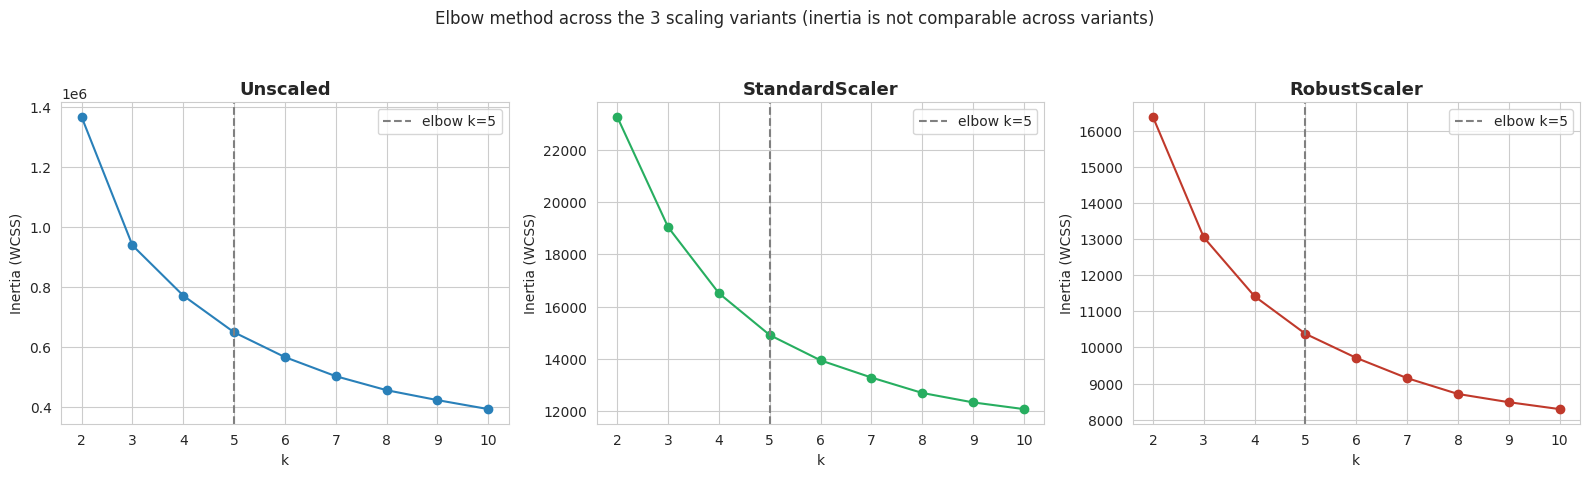

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
for ax, name in zip(axes, X_versions.keys()):
    ax.plot(K_RANGE, inertia_results[name], marker="o", color=COLORS[name])
    ax.axvline(elbow_k[name], linestyle="--", color="gray", label=f"elbow k={elbow_k[name]}")
    ax.set_title(name)
    ax.set_xlabel("k")
    ax.set_ylabel("Inertia (WCSS)")
    ax.legend()

plt.suptitle("Elbow method across the 3 scaling variants (inertia is not comparable across variants)", y=1.05)
plt.tight_layout()
plt.show()

All three variants agree on **k=5** under the kneedle heuristic — Elbow turns out to be less sensitive to scaling choice than Silhouette or Gap Statistic below.

### Silhouette score

In [75]:
silhouette_results = {}
for name, X in X_versions.items():
    sils = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        sils.append(silhouette_score(X, labels))
    silhouette_results[name] = sils

best_k_silhouette = {name: K_RANGE[int(np.argmax(vals))] for name, vals in silhouette_results.items()}
print("Best k by Silhouette:", best_k_silhouette)

Best k by Silhouette: {'Unscaled': 3, 'StandardScaler': 3, 'RobustScaler': 2}


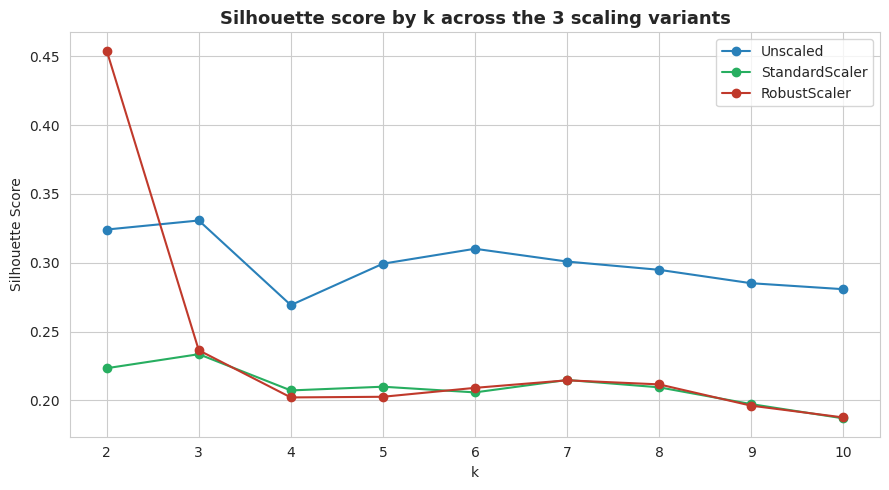

In [76]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, vals in silhouette_results.items():
    ax.plot(K_RANGE, vals, marker="o", label=name, color=COLORS[name])
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette score by k across the 3 scaling variants")
ax.legend()
plt.tight_layout()
plt.show()

`Unscaled` and `StandardScaler` both suggest k=3, while `RobustScaler` suggests k=2 with a markedly higher score (≈0.45) — likely a strong split into "defense-leaning" vs. "attack-leaning" players, the dominant axis of variation in football. Note that **absolute Silhouette values should not be compared across scaling variants** (each lives in a different metric space) — Silhouette is only used to pick `k` within a given variant.

### Gap statistic (Tibshirani rule)

In [77]:
def compute_gap_statistic(X, k_range, B=10, random_state=42):
    rng = np.random.default_rng(random_state)
    mins, maxs = X.min(axis=0), X.max(axis=0)

    def fit_inertia(data, k, seed):
        km = KMeans(n_clusters=k, n_init=10, random_state=seed)
        km.fit(data)
        return km.inertia_

    gaps, sks = [], []
    for k in k_range:
        wk_real = fit_inertia(X, k, random_state)
        log_wk_refs = []
        for b in range(B):
            X_ref = rng.uniform(low=mins, high=maxs, size=X.shape)
            wk_ref = fit_inertia(X_ref, k, random_state + b + 1)
            log_wk_refs.append(np.log(wk_ref))
        log_wk_refs = np.array(log_wk_refs)
        gap = log_wk_refs.mean() - np.log(wk_real)
        sk = log_wk_refs.std() * np.sqrt(1 + 1.0 / B)
        gaps.append(gap)
        sks.append(sk)
    return np.array(gaps), np.array(sks)


def choose_k_tibshirani(k_range, gaps, sks):
    for i in range(len(k_range) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            return k_range[i]
    return None


gap_results = {}
for name, X in X_versions.items():
    gap_results[name] = compute_gap_statistic(X, K_RANGE, B=10, random_state=42)

gap_k = {name: choose_k_tibshirani(K_RANGE, gaps, sks) for name, (gaps, sks) in gap_results.items()}
print("k chosen by Gap Statistic:", gap_k)

k chosen by Gap Statistic: {'Unscaled': None, 'StandardScaler': None, 'RobustScaler': None}


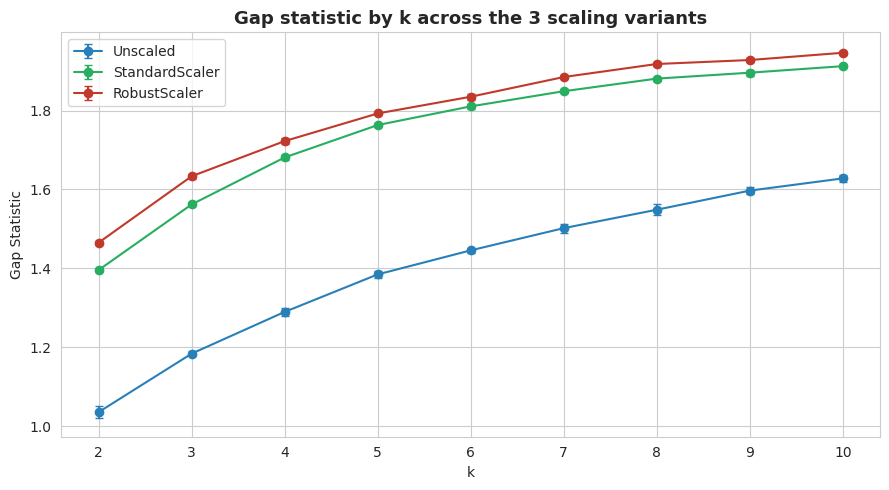

In [78]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, (gaps, sks) in gap_results.items():
    ax.errorbar(K_RANGE, gaps, yerr=sks, marker="o", capsize=3, label=name, color=COLORS[name])
ax.set_xlabel("k")
ax.set_ylabel("Gap Statistic")
ax.set_title("Gap statistic by k across the 3 scaling variants")
ax.legend()
plt.tight_layout()
plt.show()

Here with 29 features, the Gap Statistic never converges under Tibshirani's rule for any of the 3 variants (`None` for all three) — the gap keeps increasing across the whole k=2..10 range. This is likely a curse-of-dimensionality effect: with higher dimensions, the boundary between "real cluster structure" and "uniform random data" becomes harder for the Gap Statistic to detect. This is a useful negative result, and the reason no single k-selection method should be trusted alone.

### Summary of k recommendations

In [79]:
summary_k = pd.DataFrame({
    "Elbow (kneedle)": elbow_k,
    "Silhouette (max)": best_k_silhouette,
    "Gap Statistic (Tibshirani)": gap_k,
})
summary_k

,Elbow (kneedle),Silhouette (max),Gap Statistic (Tibshirani)
Unscaled,5,3,None
StandardScaler,5,3,None
RobustScaler,5,2,None


### Cross-scaler agreement (Adjusted Rand Index)

In [80]:
ari_k_range = [2, 3, 4, 5, 6]
ari_rows = []
cluster_labels_by_k = {}

for k in ari_k_range:
    labels = {}
    for name, X in X_versions.items():
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels[name] = km.fit_predict(X)
    cluster_labels_by_k[k] = labels

    ari_rows.append({
        "k": k,
        "ARI(Unscaled, StandardScaler)": adjusted_rand_score(labels["Unscaled"], labels["StandardScaler"]),
        "ARI(Unscaled, RobustScaler)": adjusted_rand_score(labels["Unscaled"], labels["RobustScaler"]),
        "ARI(StandardScaler, RobustScaler)": adjusted_rand_score(labels["StandardScaler"], labels["RobustScaler"]),
    })

ari_df = pd.DataFrame(ari_rows).set_index("k")
ari_df

,"ARI(Unscaled, StandardScaler)","ARI(Unscaled, RobustScaler)","ARI(StandardScaler, RobustScaler)"
k,,,
2,0.084,0.005,0.251
3,0.092,0.087,0.931
4,0.146,0.146,0.933
5,0.296,0.292,0.930
6,0.285,0.337,0.721


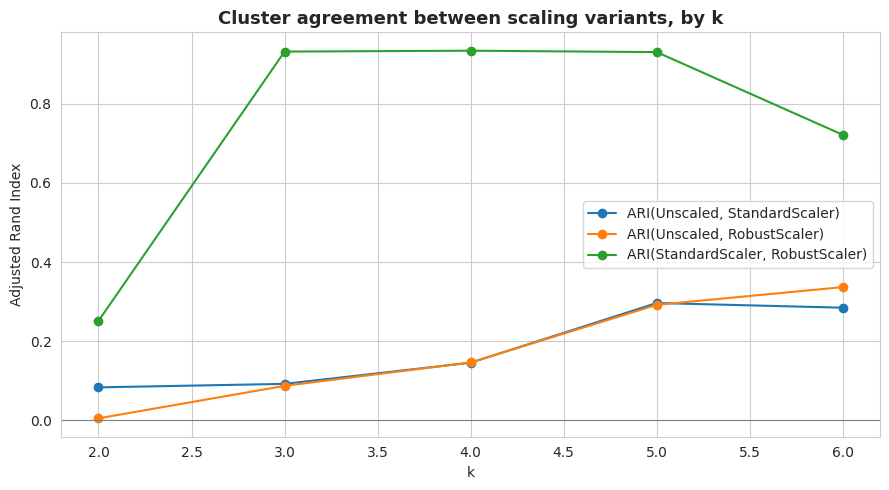

In [81]:
fig, ax = plt.subplots(figsize=(9, 5))
for col in ari_df.columns:
    ax.plot(ari_df.index, ari_df[col], marker="o", label=col)
ax.set_xlabel("k")
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("Cluster agreement between scaling variants, by k")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

**Key findings:**
- `ARI(StandardScaler, RobustScaler)` is **very high (~0.93)** across k=3-5 — the two scaled variants agree strongly on cluster structure, dropping to ~0.72 at k=6 but still substantial.
- `ARI(Unscaled, *)` stays **low (0.08-0.34)** at every k — the unscaled variant produces a clearly different cluster structure from either scaled variant.
- At k=2, `ARI(StandardScaler, RobustScaler)` is surprisingly low (0.25) even though k=2 is RobustScaler's own Silhouette-preferred value — agreement between the two scaled variants is strongest specifically in the k=3-5 range.

**Conclusion:** whether the data is scaled at all matters far more than which scaler is used — once scaled, results are fairly stable in the k=3-5 range.

### Final model: RobustScaler, k=5

**RobustScaler, k=5** is the chosen configuration: k=5 is agreed by Elbow (kneedle) across all three variants and sits inside the k=3-5 zone of strongest cross-scaler agreement; RobustScaler is kept for consistency with the Part A preprocessing decision (Part A also showed it isn't uniformly "gentler," but the ARI results above confirm the two scaled variants converge to nearly the same structure at k=5, so the choice between them has little practical impact here).

In [82]:
FINAL_SCALER = "RobustScaler"
FINAL_K = 5

final_km = KMeans(n_clusters=FINAL_K, n_init=10, random_state=42)
final_labels = final_km.fit_predict(X_versions[FINAL_SCALER])

CLUSTER_DIR = DATA_DIR / "cluster"
CLUSTER_DIR.mkdir(parents=True, exist_ok=True)

cluster_output = id_df.copy()
cluster_output["cluster_id"] = final_labels
for name in X_versions:
    cluster_output[f"cluster_id_{name}"] = cluster_labels_by_k[FINAL_K][name]

cluster_output.to_csv(CLUSTER_DIR / "player_clusters_k5.csv", index=False, encoding="utf-8-sig")
print(f"Saved: {CLUSTER_DIR / 'player_clusters_k5.csv'}")
cluster_output.head(5)

Saved: /kaggle/working/data/cluster/player_clusters_k5.csv


,player_id,player_name,primary_team,competitions_played,n_matches_played,total_minutes_played,cluster_id,cluster_id_Unscaled,cluster_id_StandardScaler,cluster_id_RobustScaler
0,3339,Asmir Begović,Chelsea,Premier League,17,1472.000,2,2,4,2
1,5594,Branislav Ivanović,Chelsea,Premier League,33,3057.000,4,0,0,4
2,3456,Kurt Happy Zouma,Chelsea,Premier League,23,2013.000,0,1,1,0
3,3645,Gary Cahill,Chelsea,Premier League,23,2061.000,0,1,1,0
4,3957,César Azpilicueta Tanco,Chelsea,Premier League,37,3351.000,4,0,0,4


In [83]:
cluster_output["cluster_id"].value_counts().sort_index()

cluster_id
0    194
1    152
2     73
3    198
4    399
Name: count, dtype: int64

### Visualizing the clusters

Three views: a **PCA 2D projection** to see how separated/overlapping the 5 clusters are, **cluster sizes** (needed context before interpreting centroids — a small cluster may be a niche/rare group), and a **feature profile heatmap** (per-cluster mean of each feature, z-scored per column only for coloring, since raw units differ wildly in scale).

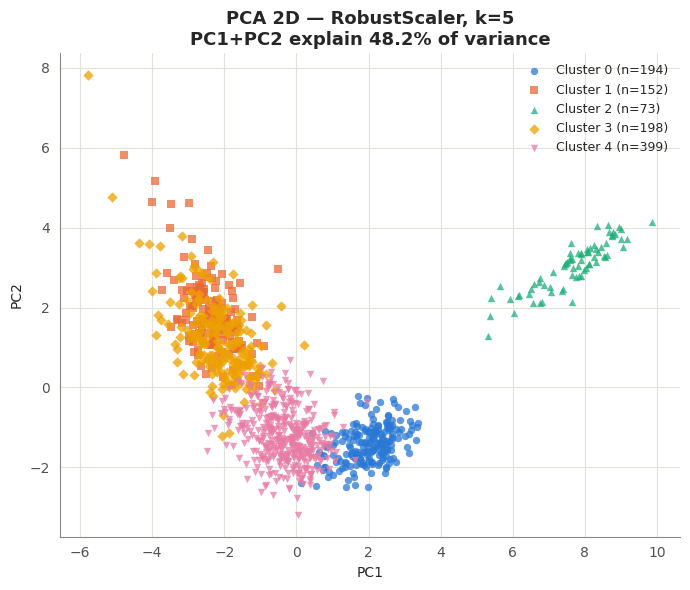

In [84]:
# Fixed palette reused for these clusters throughout notebooks 02 and 03
CLUSTER_COLORS = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a", 3: "#eda100", 4: "#e87ba4"}
CLUSTER_MARKERS = {0: "o", 1: "s", 2: "^", 3: "D", 4: "v"}
GRID_COLOR = "#e1e0d9"
MUTED_INK = "#898781"
SECONDARY_INK = "#52514e"


def style_axes(ax):
    ax.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED_INK)
    ax.tick_params(colors=SECONDARY_INK)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_versions[FINAL_SCALER])
evr = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = final_labels

fig, ax = plt.subplots(figsize=(7, 6))
for c in sorted(pca_df["cluster"].unique()):
    sub = pca_df[pca_df["cluster"] == c]
    ax.scatter(sub["PC1"], sub["PC2"], s=28, alpha=0.75, linewidths=0,
               color=CLUSTER_COLORS[c], marker=CLUSTER_MARKERS[c], label=f"Cluster {c} (n={len(sub)})")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA 2D — {FINAL_SCALER}, k={FINAL_K}\nPC1+PC2 explain {evr.sum():.1%} of variance")
style_axes(ax)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

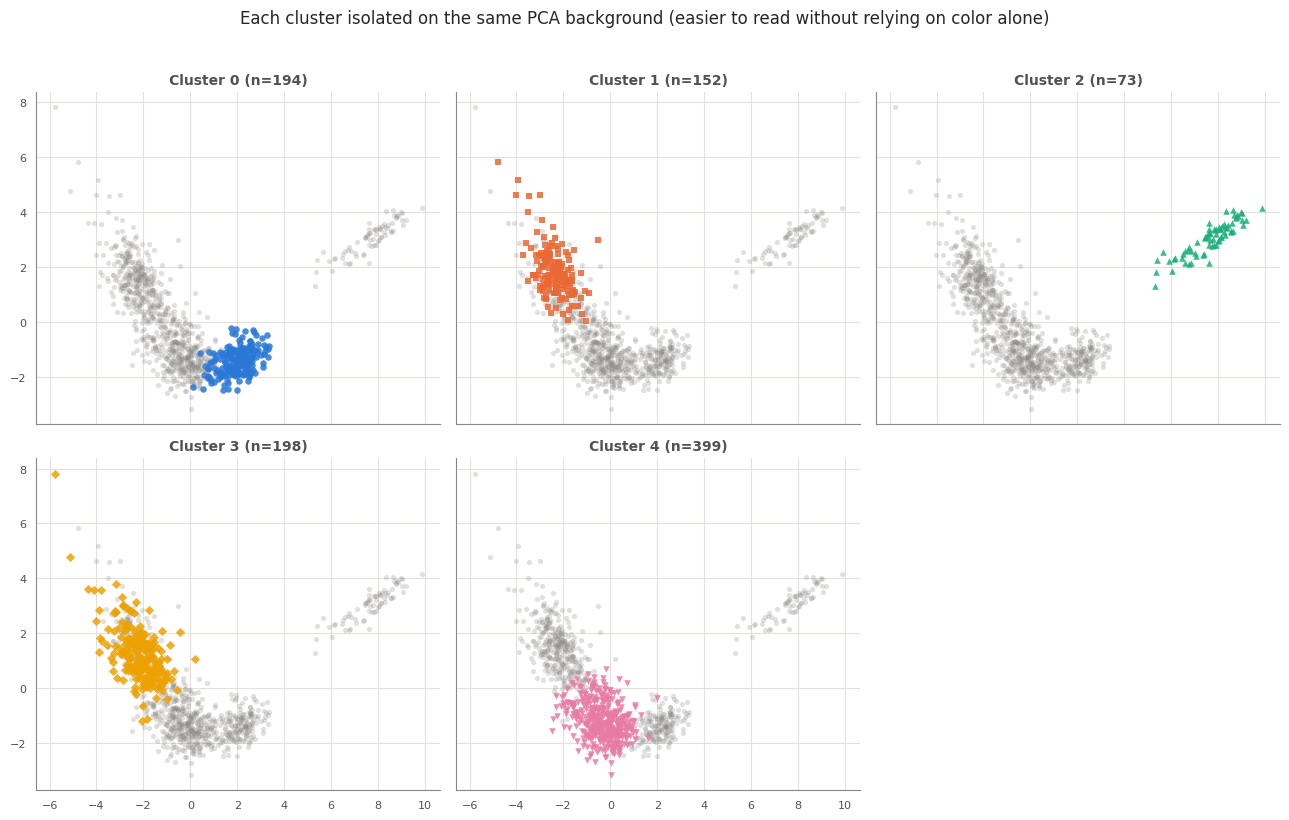

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()

for i, c in enumerate(sorted(pca_df["cluster"].unique())):
    ax = axes[i]
    other = pca_df[pca_df["cluster"] != c]
    sub = pca_df[pca_df["cluster"] == c]
    ax.scatter(other["PC1"], other["PC2"], s=14, color=MUTED_INK, alpha=0.25, linewidths=0)
    ax.scatter(sub["PC1"], sub["PC2"], s=22, color=CLUSTER_COLORS[c], marker=CLUSTER_MARKERS[c],
               alpha=0.85, linewidths=0)
    ax.set_title(f"Cluster {c} (n={len(sub)})", fontsize=10, color=SECONDARY_INK)
    style_axes(ax)
    ax.tick_params(labelsize=8)

axes[5].axis("off")  # 6 slots for 5 clusters - hide the unused one
fig.suptitle("Each cluster isolated on the same PCA background (easier to read without relying on color alone)", y=1.02)
plt.tight_layout()
plt.show()

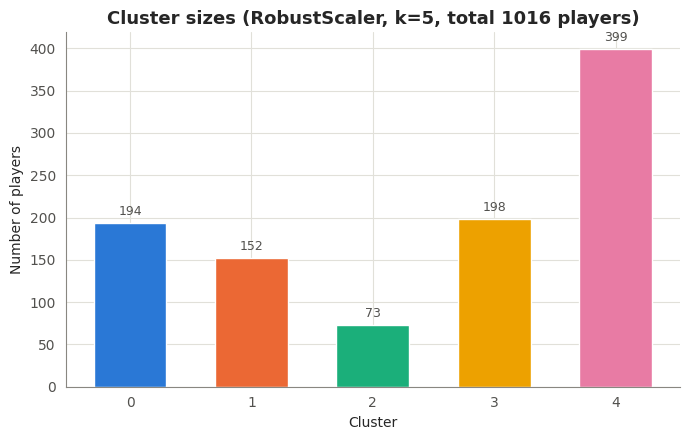

In [86]:
cluster_sizes = cluster_output["cluster_id"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(cluster_sizes.index.astype(str), cluster_sizes.values,
              color=[CLUSTER_COLORS[c] for c in cluster_sizes.index], width=0.6)
for rect, val in zip(bars, cluster_sizes.values):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 6, str(val),
            ha="center", va="bottom", fontsize=9, color=SECONDARY_INK)

ax.set_xlabel("Cluster")
ax.set_ylabel("Number of players")
ax.set_title(f"Cluster sizes ({FINAL_SCALER}, k={FINAL_K}, total {cluster_sizes.sum()} players)")
style_axes(ax)
plt.tight_layout()
plt.show()

### Feature profile heatmap

Per-cluster mean of all 29 features **in original (unscaled) units** — easier to read than RobustScaler units (e.g. goals/90 rather than a scaled score) — then z-scored per feature (across the 5 clusters) purely for heatmap coloring. Red = above the cross-cluster average for that feature, blue = below. The raw (unscaled) table is printed first for exact figures.

Raw (unscaled) mean feature values per cluster:


,shots_p90,np_goals_p90,avg_shot_distance,dribbles_p90,dribble_success_rate,touches_p90,touches_in_box_p90,passes_p90,pass_completion_pct,key_passes_p90,...,interception_success_rate,ball_recoveries_p90,clearances_p90,aerial_won_p90,fouls_committed_p90,fouls_won_p90,avg_location_x,avg_location_y,std_location_x,std_location_y
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.420,0.040,13.370,0.340,0.750,109.540,1.850,41.470,0.800,0.160,...,0.570,3.580,5.540,3.220,1.120,0.660,42.710,41.290,20.340,15.490
1,2.500,0.340,16.060,2.150,0.500,112.200,14.550,25.460,0.710,0.870,...,0.650,3.330,0.700,2.960,1.640,1.770,79.370,39.300,22.290,20.890
2,0.000,0.000,19.390,0.020,0.760,71.540,0.000,29.430,0.600,0.020,...,0.620,4.680,0.040,0.000,0.020,0.120,9.360,40.430,6.880,8.280
3,2.040,0.170,21.390,3.440,0.560,158.620,7.850,46.400,0.740,1.560,...,0.670,5.450,0.610,0.840,1.350,2.040,74.070,40.410,23.430,21.650
4,0.780,0.040,22.750,1.400,0.580,137.430,2.580,49.650,0.770,0.710,...,0.600,5.210,2.170,1.720,1.630,1.270,61.350,39.200,24.410,17.230


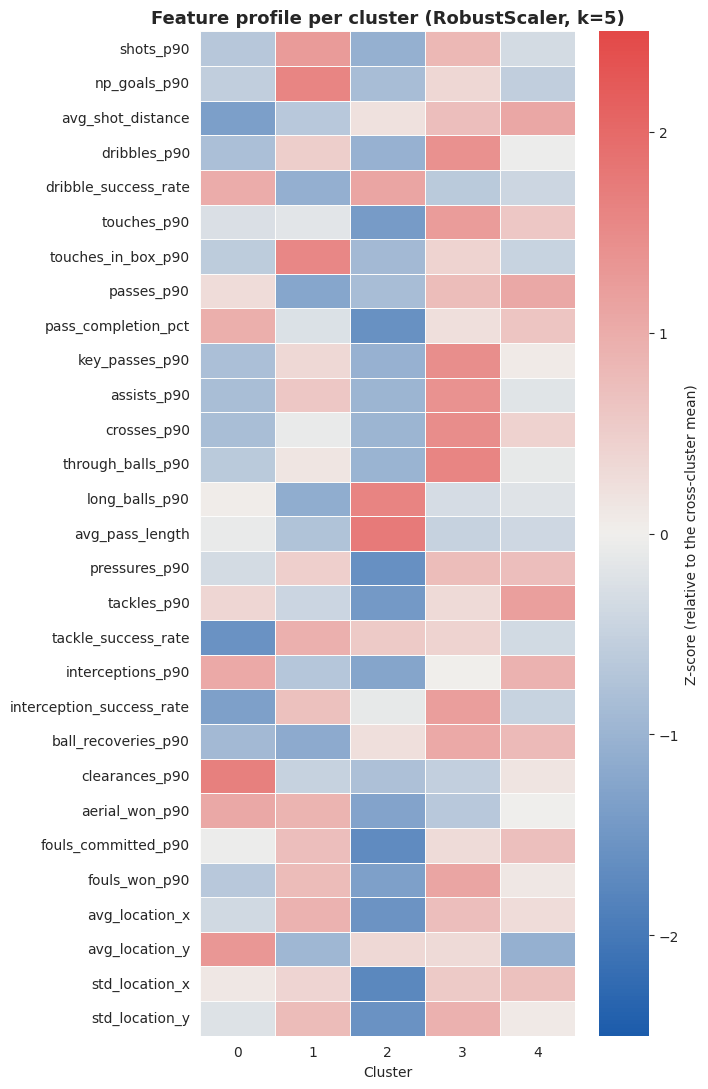

In [87]:
raw_features_df = X_unscaled.copy()
raw_features_df["cluster"] = final_labels
centroid_raw = raw_features_df.groupby("cluster")[feature_cols].mean()
centroid_z = (centroid_raw - centroid_raw.mean(axis=0)) / centroid_raw.std(axis=0)

print("Raw (unscaled) mean feature values per cluster:")
display(centroid_raw.round(2))

diverging_cmap = LinearSegmentedColormap.from_list("blue_gray_red", ["#1c5cab", "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(7, 11))
sns.heatmap(centroid_z.T, cmap=diverging_cmap, center=0, vmin=-2.5, vmax=2.5,
            linewidths=0.5, linecolor="#fcfcfb",
            cbar_kws={"label": "Z-score (relative to the cross-cluster mean)"}, ax=ax)
ax.set_xlabel("Cluster")
ax.set_ylabel("")
ax.set_title(f"Feature profile per cluster ({FINAL_SCALER}, k={FINAL_K})")
plt.tight_layout()
plt.show()

### Representative players per cluster

Lists the players closest to each cluster's centroid in the feature space used for clustering (`FINAL_SCALER`) — the most "typical" members of each cluster, useful for sanity-checking cluster identity against recognizable names. To see the full membership of a cluster (not just the top N), filter `cluster_output[cluster_output["cluster_id"] == <id>]` directly.

In [88]:
N_REPRESENTATIVE = 10

feature_matrix = X_versions[FINAL_SCALER]
centers = final_km.cluster_centers_
dist_to_centroid = np.linalg.norm(feature_matrix - centers[final_labels], axis=1)

listing_df = id_df.copy()
listing_df["cluster_id"] = final_labels
listing_df["dist_to_centroid"] = dist_to_centroid

key_stats = X_unscaled[["shots_p90", "np_goals_p90", "key_passes_p90", "tackles_p90", "interceptions_p90", "aerial_won_p90"]].copy()
key_stats["player_id"] = id_df["player_id"].values
listing_df = listing_df.merge(key_stats, on="player_id", how="left")

display_cols = [
    "player_name", "primary_team", "n_matches_played", "total_minutes_played",
    "np_goals_p90", "shots_p90", "key_passes_p90", "tackles_p90", "interceptions_p90", "aerial_won_p90",
]

for c in sorted(listing_df["cluster_id"].unique()):
    sub = listing_df[listing_df["cluster_id"] == c].sort_values("dist_to_centroid").head(N_REPRESENTATIVE)
    print(f"\n=== Cluster {c} (n={cluster_sizes[c]}) - {len(sub)} players closest to centroid ===")
    display(sub[display_cols].reset_index(drop=True).round(2))


=== Cluster 0 (n=194) - 10 players closest to centroid ===


,player_name,primary_team,n_matches_played,total_minutes_played,np_goals_p90,shots_p90,key_passes_p90,tackles_p90,interceptions_p90,aerial_won_p90
0,Bruno González Cabrera,Real Betis,32,2912.000,0.000,0.530,0.000,2.010,2.380,3.280
1,Vangelis Moras,Hellas Verona,31,2862.000,0.030,0.250,0.160,1.790,0.880,2.860
2,Marios Oikonomou,Bologna,20,1689.000,0.000,0.270,0.050,2.240,1.230,2.770
3,Eric Bertrand Bailly,Villarreal,25,2073.000,0.000,0.170,0.130,2.210,2.000,2.820
4,Martín Gastón Demichelis,Manchester City,20,1082.000,0.000,0.420,0.330,1.910,2.160,3.660
5,David Navarro Pedrós,Levante UD,20,1736.000,0.000,0.410,0.000,1.190,1.970,2.700
6,Daniel Filipe Martins Carriço,Sevilla,14,1094.000,0.080,0.580,0.000,1.480,1.810,3.460
7,Alessio Romagnoli,AC Milan,34,3070.000,0.000,0.180,0.180,1.320,1.140,3.870
8,Andrea Ranocchia,Sampdoria,24,1440.000,0.000,0.560,0.120,1.500,1.190,4.310
9,Wesley Hoedt,Lazio,25,2134.000,0.000,0.510,0.000,1.560,1.220,2.780



=== Cluster 1 (n=152) - 10 players closest to centroid ===


,player_name,primary_team,n_matches_played,total_minutes_played,np_goals_p90,shots_p90,key_passes_p90,tackles_p90,interceptions_p90,aerial_won_p90
0,José Salomón Rondón Giménez,West Bromwich Albion,34,2634.000,0.310,2.460,0.820,0.410,0.440,4.820
1,José Luis Sanmartín Mato,Stoke City,22,1164.000,0.310,2.240,0.620,0.850,0.310,4.410
2,Mame Biram Diouf,Stoke City,26,1360.000,0.330,2.120,0.460,1.190,0.530,3.040
3,Sergio Ezequiel Araújo,Las Palmas,30,1893.000,0.240,2.900,0.760,1.090,0.330,2.760
4,Massimo Maccarone,Empoli,37,2814.000,0.380,2.620,0.990,0.740,0.160,1.120
5,Eder Citadin Martins,Sampdoria,33,2466.000,0.360,2.920,0.730,1.020,0.550,0.660
6,Charles Días Barbosa de Oliveira,Málaga,35,3092.000,0.320,2.500,0.900,0.670,0.580,4.100
7,Youssef El-Arabi,Granada,35,2604.000,0.310,2.490,0.730,1.240,0.480,3.040
8,Gerard Moreno Balaguero,Espanyol,32,1978.000,0.270,2.460,0.590,1.320,0.860,2.960
9,Alberto Paloschi,Chievo,31,2404.000,0.340,2.100,0.520,0.750,0.260,1.010



=== Cluster 2 (n=73) - 10 players closest to centroid ===


,player_name,primary_team,n_matches_played,total_minutes_played,np_goals_p90,shots_p90,key_passes_p90,tackles_p90,interceptions_p90,aerial_won_p90
0,Rafael de Andrade Bittencourt Pinheiro,Hellas Verona,12,1047.000,0.000,0.000,0.090,0.000,0.000,0.000
1,Jaume Doménech Sánchez,Valencia,17,1579.000,0.000,0.000,0.060,0.000,0.000,0.060
2,Sergio Álvarez Conde,Celta Vigo,31,2824.000,0.000,0.000,0.000,0.000,0.000,0.000
3,Mattia Perin,Genoa,25,2337.000,0.000,0.000,0.040,0.000,0.000,0.000
4,Francisco Guillermo Ochoa Magaña,Málaga,11,985.000,0.000,0.000,0.000,0.000,0.000,0.000
5,Thibaut Courtois,Chelsea,23,2114.000,0.000,0.000,0.000,0.000,0.000,0.000
6,Pau López Sabata,Espanyol,36,3306.000,0.000,0.000,0.000,0.000,0.000,0.000
7,Rubén Iván Martínez Andrade,Levante UD,15,1396.000,0.000,0.000,0.000,0.000,0.000,0.000
8,David de Gea Quintana,Manchester United,34,3190.000,0.000,0.000,0.000,0.000,0.000,0.000
9,Maarten Stekelenburg,Southampton,17,1598.000,0.000,0.000,0.060,0.000,0.000,0.000



=== Cluster 3 (n=198) - 10 players closest to centroid ===


,player_name,primary_team,n_matches_played,total_minutes_played,np_goals_p90,shots_p90,key_passes_p90,tackles_p90,interceptions_p90,aerial_won_p90
0,Marco Asensio Willemsen,Espanyol,34,2900.000,0.120,1.830,1.770,1.740,0.680,0.500
1,Federico Bernardeschi,Fiorentina,33,2349.000,0.080,2.070,1.340,1.070,0.770,0.270
2,Denis Suárez Fernández,Villarreal,33,2460.000,0.150,1.350,1.500,1.900,1.390,0.730
3,Oscar dos Santos Emboaba Júnior,Chelsea,27,1839.000,0.100,2.500,1.320,3.080,0.730,0.930
4,Franco Brienza,Bologna,29,1773.000,0.150,2.080,1.570,1.070,0.960,0.760
5,Valter Birsa,Chievo,35,2379.000,0.150,2.040,1.970,1.590,0.720,1.210
6,Carlos Alberto Vela Garrido,Real Sociedad,35,2819.000,0.160,1.950,1.530,1.050,0.510,1.020
7,Willian Borges da Silva,Chelsea,35,2840.000,0.160,1.870,2.410,1.520,0.700,0.190
8,Pablo Hernández Domínguez,Rayo Vallecano,27,1957.000,0.140,1.610,1.200,1.840,1.290,0.600
9,Bruno Miguel Borges Fernandes,Udinese,31,2168.000,0.080,2.200,1.540,1.660,1.410,0.870



=== Cluster 4 (n=399) - 10 players closest to centroid ===


,player_name,primary_team,n_matches_played,total_minutes_played,np_goals_p90,shots_p90,key_passes_p90,tackles_p90,interceptions_p90,aerial_won_p90
0,Jefferson Andrés Lerma Solís,Levante UD,33,2766.000,0.030,1.200,0.780,1.820,1.720,2.470
1,James McCarthy,Everton,29,2520.000,0.070,0.610,0.500,2.930,1.210,0.710
2,Jonathan Howson,Norwich City,36,3080.000,0.090,1.020,0.790,2.400,1.110,1.310
3,José Luis García del Pozo,Málaga,33,2822.000,0.000,1.150,0.960,2.810,1.370,0.990
4,Ogenyi Eddy Onazi,Lazio,15,1219.000,0.070,0.890,0.660,2.070,1.400,1.260
5,Leandro Greco,Hellas Verona,26,1954.000,0.050,0.510,0.920,2.440,1.150,0.920
6,Pablo Fornals Malla,Málaga,27,1357.000,0.070,1.460,0.930,1.920,1.590,1.330
7,Raffaele Bianco,Carpi,26,1924.000,0.050,0.890,0.650,2.340,1.450,1.680
8,Jack Colback,Newcastle United,29,2459.000,0.040,0.590,0.620,3.370,1.570,1.610
9,Nicola Rigoni,Chievo,28,2057.000,0.130,1.310,0.310,2.360,0.960,1.230


## Results

`data/cluster/player_clusters_k5.csv` holds the official `cluster_id` (RobustScaler, k=5), along with each scaling variant's labels at k=5 for reference. `data/processed/` holds the three preprocessed feature matrices and the held-out `primary_position` labels. Ready for `03_evaluation.ipynb` — validating these clusters against `primary_position` and checking their stability with a KNN classifier.